In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def f_x1(x, mu_x, sigma_mu_nat):
    """
    Computes p_x(x | mu_x, sigma_mu_nat), where sigma_mu_nat is the stddev in natural space.
    """
    # Convert natural-space stddev to log-space stddev
    sigma_mu_log = tf.sqrt(tf.math.log(1.0 + tf.square(sigma_mu_nat / mu_x)))

    mu_alpha_x = tf.math.log(x)
    mu_alpha_mu = tf.math.log(mu_x)
    exponent = -tf.square(mu_alpha_x - mu_alpha_mu) / (2 * tf.square(sigma_mu_log))
    return tf.exp(exponent)


In [2]:
def f_x2(x, mu_x, fwhm):
    """
    Computes p_x(x | mu_x, fwhm), where fwhm is the full width at half maximum
    of the lognormal distribution with mean mu_x in natural space.
    """
    # Compute log-space sigma from FWHM
    sigma_mu_log = tf.asinh(fwhm / (np.float32(2.0) * mu_x)) / tf.sqrt(np.float32(2.0) * tf.math.log(np.float32(2.0)))

    mu_alpha_x = tf.math.log(x)
    mu_alpha_mu = tf.math.log(mu_x)
    exponent = -tf.square(mu_alpha_x - mu_alpha_mu) / (np.float32(2.0) * tf.square(sigma_mu_log))
    return tf.exp(exponent)

In [3]:
import tensorflow as tf

def f_x3(x, mu_x, fwhm):
    """
    Computes p_x(x | mu_x, fwhm), where fwhm is the full width at half maximum
    of the lognormal distribution with mean mu_x in natural space.
    """
    two = tf.constant(2.0, dtype=tf.float32)
    log2 = tf.math.log(two)
    
    # Compute log-space sigma from FWHM
    sigma_mu_log = tf.asinh(fwhm / (two * mu_x)) / tf.sqrt(two * log2)

    mu_alpha_x = tf.math.log(x)
    mu_alpha_mu = tf.math.log(mu_x)
    exponent = -tf.square(mu_alpha_x - mu_alpha_mu) / (two * tf.square(sigma_mu_log))
    return tf.exp(exponent)


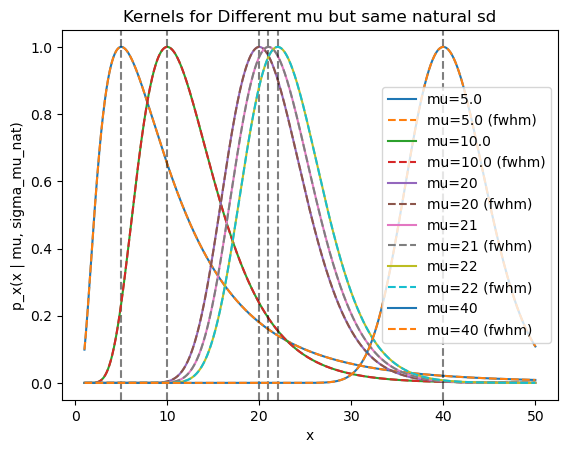

In [4]:
x = np.linspace(1, 50, 1000, dtype=np.float32)


for mu in [5.0, 10.0, 20, 21, 22, 40]:
    y = f_x2(x, np.float32(mu), np.float32(10.0))
    plt.plot(x, y, label=f'mu={mu}')
    plt.axvline(mu, color='k', linestyle='--', alpha=0.5)

    y = f_x3(x, np.float32(mu), np.float32(10.0))
    plt.plot(x, y, label=f'mu={mu} (fwhm)', ls='--')

    # y = f_x2(x, np.float32(mu), np.float32(15.0))
    # plt.plot(x, y, label=f'mu={mu}', ls='-')

plt.xlabel('x')
plt.ylabel('p_x(x | mu, sigma_mu_nat)')
plt.title('Kernels for Different mu but same natural sd')
plt.legend()

In [5]:
from neural_priors.encoding_model2.models import LinearScalingModel

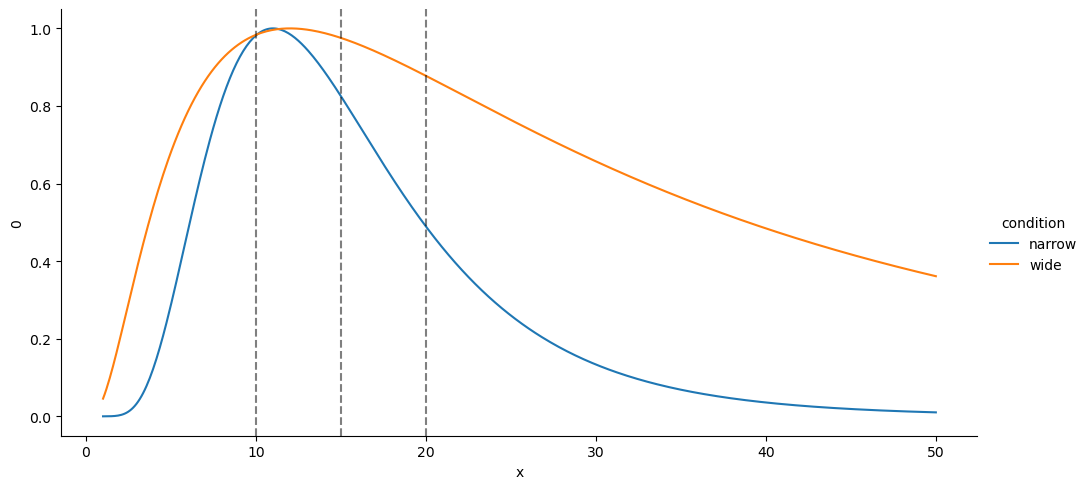

In [10]:
import pandas as pd
import seaborn as sns
parameters = pd.DataFrame([{'mu_narrow': 11.0, 'delta_wide': 2.0, 'lower_bound_range': 10.0, 'baseline': 0.0, 'sd_narrow':.5, 'amplitude': 1.0, 'sd_wide_scale':2.}])

model = LinearScalingModel(sd_natural=False, parameters=parameters, separate_sds=True)

paradigm = np.zeros((1000, 2), dtype=np.float32)
paradigm[:, 0] = np.tile(np.linspace(1., 50, 500), 2)
paradigm[:, 1] = np.repeat(np.array([0, 1]), 500)


pred = model.predict(paradigm, parameters=parameters)

pred['condition'] = pd.Series(paradigm[:, 1], dtype='category').map({0: 'narrow', 1: 'wide'})
pred['x'] = paradigm[:, 0]

sns.relplot(data=pred, x='x', y=0, hue='condition', kind='line', height=5, aspect=2)

plt.axvline(15, color='k', linestyle='--', alpha=0.5)
plt.axvline(20, color='k', linestyle='--', alpha=0.5)
plt.axvline(10, color='k', linestyle='--', alpha=0.5)

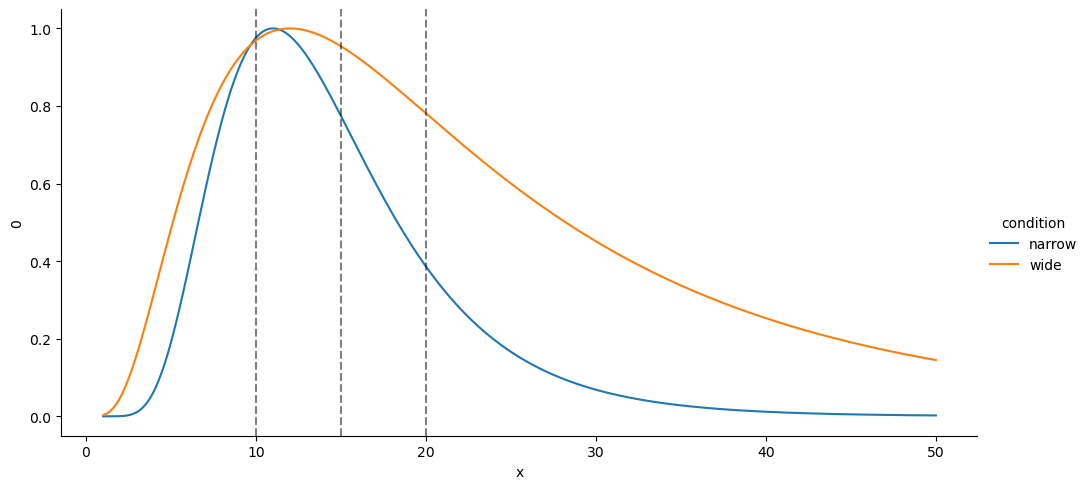

In [11]:
import pandas as pd
import seaborn as sns

model.parameter_labels



parameters = pd.DataFrame([{'mu_narrow': 11.0, 'delta_wide': 2.0, 'lower_bound_range': 10.0, 'baseline': 0.0, 'sd_narrow':5., 'amplitude': 1.0, 'sd_wide_scale':2.}])

model = LinearScalingModel(sd_natural=True, parameters=parameters, separate_sds=True)

paradigm = np.zeros((1000, 2), dtype=np.float32)
paradigm[:, 0] = np.tile(np.linspace(1., 50, 500), 2)
paradigm[:, 1] = np.repeat(np.array([0, 1]), 500)


pred = model.predict(paradigm, parameters=parameters)

pred['condition'] = pd.Series(paradigm[:, 1], dtype='category').map({0: 'narrow', 1: 'wide'})
pred['x'] = paradigm[:, 0]

sns.relplot(data=pred, x='x', y=0, hue='condition', kind='line', height=5, aspect=2)

plt.axvline(15, color='k', linestyle='--', alpha=0.5)
plt.axvline(20, color='k', linestyle='--', alpha=0.5)
plt.axvline(10, color='k', linestyle='--', alpha=0.5)

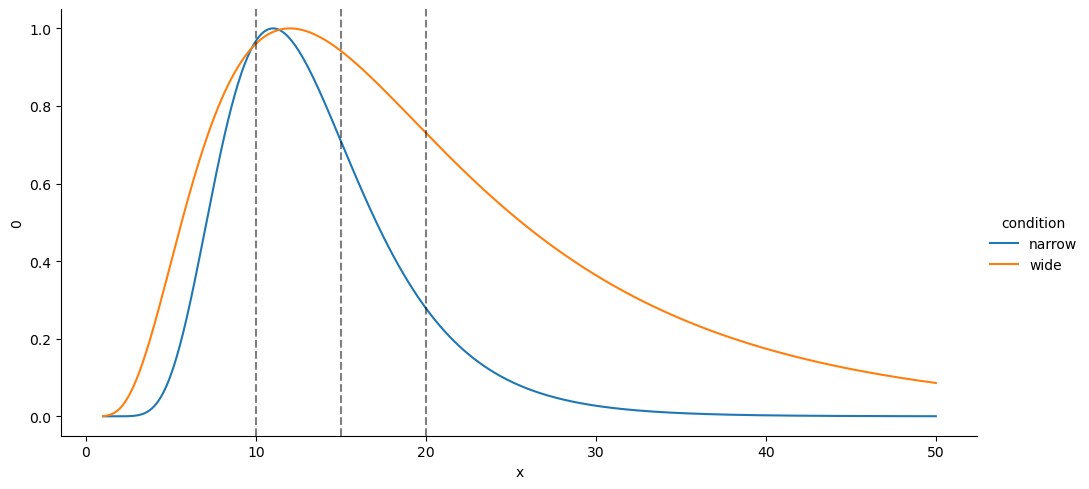

In [12]:
import pandas as pd
import seaborn as sns

model.parameter_labels



parameters = pd.DataFrame([{'mu_narrow': 11.0, 'delta_wide': 2.0, 'lower_bound_range': 10.0, 'baseline': 0.0, 'sd_narrow':10., 'amplitude': 1.0, 'sd_wide_scale':2.}])

model = LinearScalingModel(sigma_fwhm=True, parameters=parameters, separate_sds=True)

paradigm = np.zeros((1000, 2), dtype=np.float32)
paradigm[:, 0] = np.tile(np.linspace(1., 50, 500), 2)
paradigm[:, 1] = np.repeat(np.array([0, 1]), 500)


pred = model.predict(paradigm, parameters=parameters)

pred['condition'] = pd.Series(paradigm[:, 1], dtype='category').map({0: 'narrow', 1: 'wide'})
pred['x'] = paradigm[:, 0]

sns.relplot(data=pred, x='x', y=0, hue='condition', kind='line', height=5, aspect=2)

plt.axvline(15, color='k', linestyle='--', alpha=0.5)
plt.axvline(20, color='k', linestyle='--', alpha=0.5)
plt.axvline(10, color='k', linestyle='--', alpha=0.5)